### Plan-Execute 패턴

Plan-Execute 패턴은 복잡한 작업을 효율적으로 처리하기 위한 방법론이다. 이 패턴은 작업을 두 가지 주요 단계, 즉 **계획**(Plan)과 **실행**(Execute)으로 나누어 진행하는 것이 특징이다.

---

### 각 단계의 역할

-   **계획**(Plan) 단계는 사용자의 요청을 분석하고 목표 달성을 위한 구체적인 단계를 수립하는 것이다. 이 과정에서 어떤 정보를 검색하고 어떤 작업을 수행할지 미리 정한다.
-   **실행**(Execute) 단계는 수립된 계획의 각 단계를 순차적으로 수행하는 것이다. 각 단계의 결과는 다음 단계의 입력으로 사용되며, 모든 단계가 완료되면 최종 결과가 도출된다.

이 패턴은 각 단계의 역할이 명확하여, 복잡한 문제 해결 과정을 체계적이고 논리적으로 만드는 데 유용하다. 여러 도구를 순차적으로 사용해야 하는 경우에 특히 효과적인 방법이다.

In [ ]:
from langchain_core.tools import tool
from langchain_community.tools import DuckDuckGoSearchResults
from langchain_community.utilities import DuckDuckGoSearchAPIWrapper
  
@tool
def get_web_search(query: str, search_period: str='m') -> str:
    """
    웹 검색을 수행하는 함수.
    """
    wrapper = DuckDuckGoSearchAPIWrapper(
        # region="kr-kr", 
        time=search_period
    )

    print('\n-------- WEB SEARCH --------')
    print(query)
    print(search_period)

    search = DuckDuckGoSearchResults(
        api_wrapper=wrapper,
        # source="news",
        results_separator=';\n'
    )

    searched = search.invoke(query)
    
    for i, result in enumerate(searched.split(';\n')):
        print(f'{i+1}. {result}')
    
    return searched

# 도구 바인딩
tools = [get_web_search]

In [2]:
from langchain_google_genai import ChatGoogleGenerativeAI

from dotenv import load_dotenv
load_dotenv()

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)

E0000 00:00:1758803676.082374  108756 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


In [3]:
from langgraph.prebuilt import create_react_agent
from langchain_core.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful assistant. Answer in Korean.",
        ),
        ("human", "{messages}"),
    ]
)


# ReAct 에이전트 생성
agent_executor = create_react_agent(llm, tools, prompt=prompt)

In [4]:
query = "케이팝데몬헌터스에 대해 설명해줘."

In [5]:
from langchain_core.messages import HumanMessage

# 에이전트 실행
agent_executor.invoke(
    {"messages": [HumanMessage(content=query)]}
)


-------- WEB SEARCH --------
케이팝데몬헌터스
m
1. snippet: 1 day ago - 《케이팝 데몬 헌터스》(영어: KPop Demon Hunters)는 2025년 공개된 미국의 뮤지컬, 판타지, 코미디 애니메이션 영화이다. 소니 픽처스 애니메이션이 제작하고 넷플릭스가 배급한다. 매기 강과 크리스 아펠한스가 감독을 맡았으며, ..., title: Wikipedia 케이팝 데몬 헌터스 - 위키백과, 우리 모두의 ..., link: https://ko.wikipedia.org/wiki/케이팝_데몬_헌터스
2. snippet: 3 weeks ago - KPop Demon Hunters (Soundtrack from the Netflix Film)는 2025년 애니메이션 뮤지컬 판타지 영화인 케이팝 데몬 헌터스의 사운드트랙 음반으로, 2025년 6월 20일 리퍼블릭 레코드를 통해 발매되었다. 대니 정, 이도, 빈스, 쿠쉬, Ejae, 제나 ..., title: Wikipedia KPop Demon Hunters (사운드트랙) - 위키백과, 우리 모두의 ..., link: https://ko.wikipedia.org/wiki/KPop_Demon_Hunters_(사운드트랙)
3. snippet: 케이팝데몬헌터스 진우, 데몬헌터스 조이, KPop Demon Hunters 진우, 케이팝 진우 더빙, Netflix 케이팝데몬헌터스 마지막 업데이트 2025-08-18., title: 케이팝데몬헌터스 진ㅇ우 | TikTok, link: https://www.tiktok.com/discover/케이팝데몬헌터스-진ㅇ우
4. snippet: Воспроизвести все. 케이팝데몬헌터스 . 냥냥미용. Плейлист • 14 видео • 26 просмотров., title: 케이팝데몬헌터스 - YouTube, link: https://www.youtube.com/playlist?list=PL6qjaO1Xo42rJZzaPU758o3PGkX0V0dK

{'messages': [HumanMessage(content='케이팝데몬헌터스에 대해 설명해줘.', additional_kwargs={}, response_metadata={}, id='b360ff30-ec38-43a7-8689-026be4eb5228'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'get_web_search', 'arguments': '{"query": "\\ucf00\\uc774\\ud31d\\ub370\\ubaac\\ud5cc\\ud130\\uc2a4"}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--a77e7393-3f2b-4e17-8ab1-894869384b68-0', tool_calls=[{'name': 'get_web_search', 'args': {'query': '케이팝데몬헌터스'}, 'id': '26488e10-f241-4a77-a440-cba7e303b261', 'type': 'tool_call'}], usage_metadata={'input_tokens': 133, 'output_tokens': 94, 'total_tokens': 227, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 71}}),
  ToolMessage(content='snippet: 1 day ago - 《케이팝 데몬 헌터스》(영어: KPop Demon Hunters)는 2025년 공개된 미국의 뮤지컬, 판타지, 코미디 애니메이션 영화이다. 소니 픽처스 애니메이션이 제작하고 넷플릭스가 배급한다. 매기 강과 크리스

In [6]:
import operator
from typing import Annotated, List, Tuple
from typing_extensions import TypedDict


# 상태 정의
class PlanExecute(TypedDict):
    input: Annotated[str, "User's input"]
    plan: Annotated[List[str], "Current plan"]
    past_steps: Annotated[List[Tuple], operator.add]
    response: Annotated[str, "Final response"]

In [7]:
from pydantic import BaseModel, Field
from typing import List


# Plan 모델 정의
class Plan(BaseModel):
    """Sorted steps to execute the plan"""

    steps: Annotated[List[str], "Different steps to follow, should be in sorted order"]

In [8]:
from langchain_core.prompts import ChatPromptTemplate

# 계획 수립을 위한 프롬프트 템플릿 생성
planner_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """주어진 목표에 대해 간단한 단계별 계획을 세워주세요. \
이 계획은 정확한 답을 도출하는 데 필요한 개별적인 작업들로 구성되어야 합니다. \
불필요한 단계는 추가하지 마세요. 마지막 단계의 결과가 최종 답변이어야 합니다. \
각 단계에 필요한 모든 정보가 포함되어 있는지 확인하고, 단계를 건너뛰지 마세요.
답변은 한글로 작성하세요.""",
        ),
        ("placeholder", "{messages}"),
    ]
)

planner = planner_prompt | ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0).with_structured_output(Plan)

E0000 00:00:1758803682.800532  108756 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


In [9]:
from langchain.schema import HumanMessage

# Planner 실행
planner.invoke(
    {
        "messages": [
            HumanMessage(content=query)
        ]
    }
)

Plan(steps=['"케이팝데몬헌터스"에 대한 정보를 검색합니다.', '검색된 정보를 바탕으로 "케이팝데몬헌터스"가 무엇인지 설명합니다.'])

In [10]:
from typing import Literal
from pydantic import BaseModel, Field

# 사용자 응답
class Response(BaseModel):
    """Response to user."""
    # 사용자 응답
    response: str = Field(description="The final response to the user.")

# 계획 재수립
class Plan(BaseModel):
    """Action to perform."""
    # 수행할 작업: "Response", "Plan".
    steps: list[str] = Field(description="List of steps to be performed.")


# 계획을 재수립하기 위한 프롬프트 정의
replanner_prompt = ChatPromptTemplate.from_template(
    """주어진 목표에 대해 간단한 단계별 계획을 세워주세요. \
이 계획은 정확한 답을 도출하는 데 필요한 개별적인 작업들로 구성되어야 합니다. \
불필요한 단계는 추가하지 마세요. 마지막 단계의 결과가 최종 답변이어야 합니다. \
각 단계에 필요한 모든 정보가 포함되어 있는지 확인하고, 단계를 건너뛰지 마세요.

당신의 목표는 다음과 같습니다:
{input}

당신의 원래 계획은 다음과 같습니다:
{plan}

당신이 현재까지 완료한 단계는 다음과 같습니다:
{past_steps}

계획을 적절하게 업데이트하세요. 더 이상 필요한 단계가 없고 사용자에게 답변을 반환할 수 있다면, 그것으로 응답하세요. \
그렇지 않다면, 계획을 다시 작성하세요. 아직 완료되지 않은 단계만 계획에 추가하세요. \
이전에 완료한 단계를 계획에 다시 포함시키지 마세요.

답변은 한글로 작성하세요."""
)


# Replanner 생성
replanner = replanner_prompt | ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0).bind_tools(
    tools=[Response, Plan],
    # tool_choice=Literal["Response", "Plan"]
)

E0000 00:00:1758803686.326749  108756 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


In [11]:
from langchain_core.output_parsers import StrOutputParser


# 사용자 입력을 기반으로 계획을 생성하고 반환
def plan_step(state: PlanExecute):
    plan = planner.invoke({"messages": [("user", state["input"])]})
    # 생성된 계획의 단계 리스트 반환
    return {"plan": plan.steps}


# 에이전트 실행기를 사용하여 주어진 작업을 수행하고 결과를 반환
def execute_step(state: PlanExecute):
    plan = state["plan"]
    # 계획을 문자열로 변환하여 각 단계에 번호를 매김
    plan_str = "\n".join(f"{i+1}. {step}" for i, step in enumerate(plan))
    task = plan[0]
    # 현재 실행할 작업을 포맷팅하여 에이전트에 전달
    task_formatted = f"""For the following plan:
{plan_str}\n\nYou are tasked with executing [step 1. {task}]."""
    # 에이전트 실행기를 통해 작업 수행 및 결과 수신
    agent_response = agent_executor.invoke({"messages": [("user", task_formatted)]})
    # 이전 단계와 그 결과를 포함하는 딕셔너리 반환
    return {
        "past_steps": [(task, agent_response["messages"][-1].content)],
    }


# 이전 단계의 결과를 바탕으로 계획을 업데이트하거나 최종 응답을 반환
def replan_step(state: PlanExecute):
    output = replanner.invoke(state)

    # 모델이 도구 호출을 생성했는지 확인
    if output.tool_calls:
        tool_call = output.tool_calls[0]
        tool_name = tool_call['name']
        tool_args = tool_call['args']

        # 도구 이름에 따라 분기
        if tool_name == 'Response':
            return {"response": tool_args.get('response')}
        elif tool_name == 'Plan':
            return {"plan": tool_args.get('steps')}
    
    # 도구 호출이 없는 경우 (일반적인 메시지)
    return {"response": output.content}


# 에이전트의 실행 종료 여부를 결정하는 함수
def should_end(state: PlanExecute):
    if "response" in state and state["response"]:
        return "final_report"
    else:
        return "execute"


final_report_prompt = ChatPromptTemplate.from_template(
    """당신에게는 목표와 이전에 완료된 단계들이 주어졌습니다. 당신의 임무는 마크다운 형식으로 최종 보고서를 생성하는 것입니다.
최종 보고서는 전문적인 어조로 작성되어야 합니다.

당신의 목표는 다음과 같습니다:

{input}

이전에 완료된 단계들(질문과 답변 쌍):

{past_steps}

마크다운 형식으로 최종 보고서를 생성하세요. 답변은 한글로 작성하세요."""
)

final_report = (
    final_report_prompt
    | ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)
    | StrOutputParser()
)


def generate_final_report(state: PlanExecute):
    past_steps = "\n\n".join(
        [
            f"Question: {past_step[0]}\n\nAnswer: {past_step[1]}\n\n####"
            for past_step in state["past_steps"]
        ]
    )
    response = final_report.invoke({"input": state["input"], "past_steps": past_steps})
    return {"response": response}

E0000 00:00:1758803686.334727  108756 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


In [12]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver


# 그래프 생성
workflow = StateGraph(PlanExecute)

# 노드 정의
workflow.add_node("planner", plan_step)
workflow.add_node("execute", execute_step)
workflow.add_node("replan", replan_step)
workflow.add_node("final_report", generate_final_report)

# 엣지 정의
workflow.add_edge(START, "planner")
workflow.add_edge("planner", "execute")
workflow.add_edge("execute", "replan")
workflow.add_edge("final_report", END)

# 조건부 엣지: replan 후 종료 여부를 결정하는 함수 사용
workflow.add_conditional_edges(
    "replan",
    should_end,
    {"execute": "execute", "final_report": "final_report"},
)

# 그래프 컴파일
app = workflow.compile(checkpointer=MemorySaver())

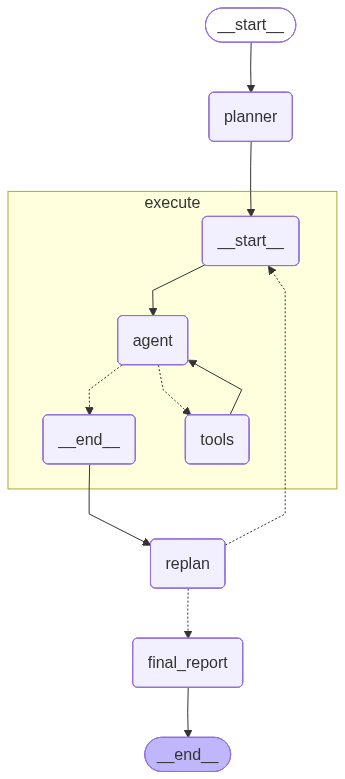

In [13]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    pass

In [14]:
import uuid

# 에이전트 실행
result = app.invoke(
    {"input": query},
    config={"configurable": {"thread_id": str(uuid.uuid4())}}
)

# 결과 출력
print(result)


-------- WEB SEARCH --------
케이팝데몬헌터스
m
1. snippet: 1 day ago - 《케이팝 데몬 헌터스》(영어: KPop Demon Hunters)는 2025년 공개된 미국의 뮤지컬, 판타지, 코미디 애니메이션 영화이다. 소니 픽처스 애니메이션이 제작하고 넷플릭스가 배급한다. 매기 강과 크리스 아펠한스가 감독을 맡았으며, ..., title: Wikipedia 케이팝 데몬 헌터스 - 위키백과, 우리 모두의 ..., link: https://ko.wikipedia.org/wiki/케이팝_데몬_헌터스
2. snippet: 3 weeks ago - KPop Demon Hunters (Soundtrack from the Netflix Film)는 2025년 애니메이션 뮤지컬 판타지 영화인 케이팝 데몬 헌터스의 사운드트랙 음반으로, 2025년 6월 20일 리퍼블릭 레코드를 통해 발매되었다. 대니 정, 이도, 빈스, 쿠쉬, Ejae, 제나 ..., title: Wikipedia KPop Demon Hunters (사운드트랙) - 위키백과, 우리 모두의 ..., link: https://ko.wikipedia.org/wiki/KPop_Demon_Hunters_(사운드트랙)
3. snippet: #해외반응 # 케이팝데몬헌터스 채널에 가입하여 혜택을 누려보세요.https://www.youtube.com/channel/UCrMGh7NV4sZlZQTaK0kWMAQ/join우리나라 및 세계에서 일어나고 있는 다양한 이야기를 공유하는 채널입니다. 영미권 소식은 직접 번역하여 ..., title: YouTube "케데헌 진우 존재감 이정도라고?" 역대급 반응에 빵 터진 패널들 ㅋㅋㅋ, 차세대 대세가 된 한국문화에 난리난 호주 캐나다 미국 방송 - YouTube, link: https://www.youtube.com/watch?v=Bb3F44Z_VDM
4. snippet: 1 month ago - Tags #CEONEWS #박수남 #박수남 기자 #K콘텐

In [15]:
import pprint

pprint.pprint(result)

{'input': '케이팝데몬헌터스에 대해 설명해줘.',
 'past_steps': [('케이팝데몬헌터스에 대한 정보를 검색합니다.',
                 '케이팝 데몬 헌터스에 대한 정보를 검색한 결과, 다음과 같은 내용을 찾았습니다:\n'
                 '\n'
                 '*   **케이팝 데몬 헌터스**는 2025년에 공개된 미국의 뮤지컬, 판타지, 코미디 애니메이션 '
                 '영화입니다.\n'
                 '*   소니 픽처스 애니메이션이 제작하고 넷플릭스가 배급합니다.\n'
                 '*   매기 강과 크리스 아펠한스가 감독을 맡았습니다.\n'
                 '*   이 영화의 사운드트랙 음반도 2025년 6월 20일에 발매되었습니다.\n'
                 '*   관련하여 해외 반응 및 K-콘텐츠로서의 영향력에 대한 기사도 있습니다.\n'
                 '\n'
                 '따라서 검색 결과가 충분하므로 케이팝 데몬 헌터스에 대한 설명을 제공할 수 있습니다.'),
                ('케이팝데몬헌터스에 대한 설명을 제공합니다.',
                 '《케이팝 데몬 헌터스》는 2025년에 공개된 미국의 뮤지컬, 판타지, 코미디 애니메이션 영화입니다. 소니 '
                 '픽처스 애니메이션이 제작하고 넷플릭스가 배급하며, 매기 강과 크리스 아펠한스가 감독을 맡았습니다.\n'
                 '\n'
                 "이 영화는 세계적으로 인기를 끌고 있는 K-POP 걸그룹 'HUNTR/X'의 멤버들인 루미, 미라, 조이를 "
                 '중심으로 이야기가 전개됩니다. 또한, 2025년 6월 20일에는 리퍼블릭 레코드를 통해 사운드트랙 음반이 '
                 '발매되었습니